In [1]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
grid_dir = Path("/home/c4011027/PhD_stuff/SPAMMS/Outputs/results/zetaR_zetaT_inc_vcrit_grid")

target_sigma_R = 200.0
target_sigma_T = 300.0
target_vcrit = [0.1, 0.5, 0.9]
target_incl = [10.0, 30.0, 90.0]

def parse_model_info(model_info_path):
    """
    Parse model_info.txt and return a dictionary of parameter values.
    This is written flexibly because model_info.txt formatting can vary slightly.
    """
    params = {}

    with open(model_info_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        line = line.strip()
        if not line or line.startswith("#"):
            continue

        # Handles formats like:
        # inclination = 30
        # inclination: 30
        # inclination 30
        parts = re.split(r"\s*[:=]\s*|\s+", line)

        if len(parts) >= 2:
            key = parts[0].strip()
            val = parts[-1].strip()

            try:
                params[key] = float(val)
            except ValueError:
                params[key] = val

    return params


rows = []

for model_dir in sorted(grid_dir.glob("Model_*")):
    model_info = model_dir / "model_info.txt"

    if not model_info.exists():
        continue

    params = parse_model_info(model_info)

    row = {
        "model_dir": str(model_dir),
        "model_name": model_dir.name,
        "inclination": params.get("inclination", np.nan),
        "v_crit_frac": params.get("v_crit_frac", np.nan),
        "sigma_R": params.get("sigma_R", np.nan),
        "sigma_T": params.get("sigma_T", np.nan),
    }

    rows.append(row)

df_models = pd.DataFrame(rows)

matches = df_models[
    np.isclose(df_models["sigma_R"], target_sigma_R)
    & np.isclose(df_models["sigma_T"], target_sigma_T)
    & df_models["v_crit_frac"].apply(lambda x: any(np.isclose(x, target_vcrit)))
    & df_models["inclination"].apply(lambda x: any(np.isclose(x, target_incl)))
].copy()

matches = matches.sort_values(["inclination", "v_crit_frac"]).reset_index(drop=True)

print(matches)
print(f"\nFound {len(matches)} matching models out of expected 9.")

                                           model_dir  model_name  inclination  \
0  /home/c4011027/PhD_stuff/SPAMMS/Outputs/result...  Model_0400         10.0   
1  /home/c4011027/PhD_stuff/SPAMMS/Outputs/result...  Model_0410         10.0   
2  /home/c4011027/PhD_stuff/SPAMMS/Outputs/result...  Model_0420         10.0   
3  /home/c4011027/PhD_stuff/SPAMMS/Outputs/result...  Model_0401         30.0   
4  /home/c4011027/PhD_stuff/SPAMMS/Outputs/result...  Model_0411         30.0   
5  /home/c4011027/PhD_stuff/SPAMMS/Outputs/result...  Model_0421         30.0   
6  /home/c4011027/PhD_stuff/SPAMMS/Outputs/result...  Model_0404         90.0   
7  /home/c4011027/PhD_stuff/SPAMMS/Outputs/result...  Model_0414         90.0   
8  /home/c4011027/PhD_stuff/SPAMMS/Outputs/result...  Model_0424         90.0   

   v_crit_frac  sigma_R  sigma_T  
0          0.1    200.0    300.0  
1          0.5    200.0    300.0  
2          0.9    200.0    300.0  
3          0.1    200.0    300.0  
4          0.5

In [3]:
line_name = "HEII4200"

profile_rows = []

for _, row in matches.iterrows():
    model_dir = Path(row["model_dir"])

    profile_files = list(model_dir.glob(f"**/*{line_name}*.txt"))

    if len(profile_files) == 0:
        profile_file = None
    elif len(profile_files) == 1:
        profile_file = profile_files[0]
    else:
        print(f"Multiple profile files found in {model_dir}:")
        for p in profile_files:
            print("   ", p)
        profile_file = profile_files[0]

    profile_rows.append({
        **row.to_dict(),
        "profile_file": str(profile_file) if profile_file is not None else None,
    })

df_profiles = pd.DataFrame(profile_rows)

print(df_profiles[[
    "model_name", "inclination", "v_crit_frac", "sigma_R", "sigma_T", "profile_file"
]])

   model_name  inclination  v_crit_frac  sigma_R  sigma_T  \
0  Model_0400         10.0          0.1    200.0    300.0   
1  Model_0410         10.0          0.5    200.0    300.0   
2  Model_0420         10.0          0.9    200.0    300.0   
3  Model_0401         30.0          0.1    200.0    300.0   
4  Model_0411         30.0          0.5    200.0    300.0   
5  Model_0421         30.0          0.9    200.0    300.0   
6  Model_0404         90.0          0.1    200.0    300.0   
7  Model_0414         90.0          0.5    200.0    300.0   
8  Model_0424         90.0          0.9    200.0    300.0   

                                        profile_file  
0  /home/c4011027/PhD_stuff/SPAMMS/Outputs/result...  
1  /home/c4011027/PhD_stuff/SPAMMS/Outputs/result...  
2  /home/c4011027/PhD_stuff/SPAMMS/Outputs/result...  
3  /home/c4011027/PhD_stuff/SPAMMS/Outputs/result...  
4  /home/c4011027/PhD_stuff/SPAMMS/Outputs/result...  
5  /home/c4011027/PhD_stuff/SPAMMS/Outputs/result...  
6  /

In [4]:
df_profiles

,model_dir,model_name,inclination,v_crit_frac,sigma_R,sigma_T,profile_file
0,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...,Model_0400,10.0,0.1,200.0,300.0,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...
1,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...,Model_0410,10.0,0.5,200.0,300.0,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...
2,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...,Model_0420,10.0,0.9,200.0,300.0,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...
3,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...,Model_0401,30.0,0.1,200.0,300.0,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...
4,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...,Model_0411,30.0,0.5,200.0,300.0,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...
5,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...,Model_0421,30.0,0.9,200.0,300.0,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...
6,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...,Model_0404,90.0,0.1,200.0,300.0,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...
7,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...,Model_0414,90.0,0.5,200.0,300.0,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...
8,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...,Model_0424,90.0,0.9,200.0,300.0,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...


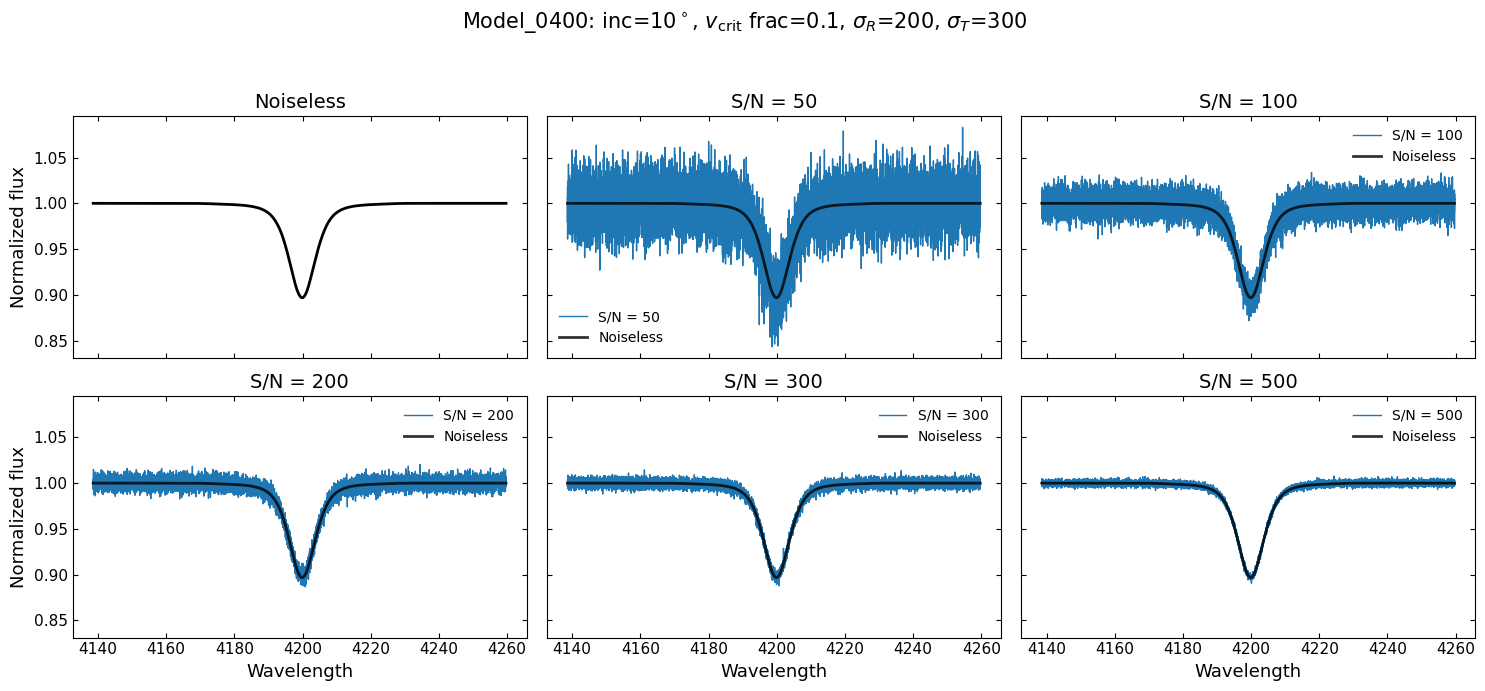

In [5]:
row = df_profiles.iloc[0]

profile_file = Path(row["profile_file"])
model_name = row["model_name"]
inc = row["inclination"]
vcrit = row["v_crit_frac"]
sigma_R = row["sigma_R"]
sigma_T = row["sigma_T"]

snr_values = [50, 100, 200, 300, 500]
rng = np.random.default_rng(42)

# Read profile
data = np.loadtxt(profile_file)
wave = data[:, 0]
flux = data[:, 1]

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True, sharey=True)
axes = axes.ravel()

# Panel 1: noiseless profile
axes[0].plot(wave, flux, lw=2.0, color="black")
axes[0].set_title("Noiseless", fontsize=14)
axes[0].set_ylabel("Normalized flux", fontsize=13)

# Other panels: noisy profiles + noiseless overplot
for ax, snr in zip(axes[1:], snr_values):
    noise_sigma = 1.0 / snr
    noisy_flux = flux + rng.normal(0.0, noise_sigma, size=flux.size)

    ax.plot(wave, noisy_flux, lw=1.0, color="tab:blue", label=f"S/N = {snr}")
    ax.plot(wave, flux, lw=2.0, color="black", alpha=0.8, label="Noiseless")

    ax.set_title(f"S/N = {snr}", fontsize=14)
    ax.legend(fontsize=10, frameon=False)

# Axis labels
for ax in axes[3:]:
    ax.set_xlabel("Wavelength", fontsize=13)

for ax in axes[::3]:
    ax.set_ylabel("Normalized flux", fontsize=13)

for ax in axes:
    ax.tick_params(axis="both", labelsize=11, direction="in", top=True, right=True)

fig.suptitle(
    rf"{model_name}: inc={inc:.0f}$^\circ$, $v_\mathrm{{crit}}$ frac={vcrit:.1f}, "
    rf"$\sigma_R$={sigma_R:.0f}, $\sigma_T$={sigma_T:.0f}",
    fontsize=15,
)

fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

In [6]:
snr = 300
rng = np.random.default_rng(42)

obs_row = df_profiles.iloc[0]   # first of your selected 9 models
obs_file = Path(obs_row["profile_file"])

fit_window = None
# fit_window = (4185, 4215)

obs_data = np.loadtxt(obs_file)
wave_obs = obs_data[:, 0]
flux_true = obs_data[:, 1]

if fit_window is not None:
    mask_obs = (wave_obs >= fit_window[0]) & (wave_obs <= fit_window[1])
    wave_obs = wave_obs[mask_obs]
    flux_true = flux_true[mask_obs]

sigma_flux = 1.0 / snr
flux_noisy = flux_true + rng.normal(0.0, sigma_flux, size=flux_true.size)

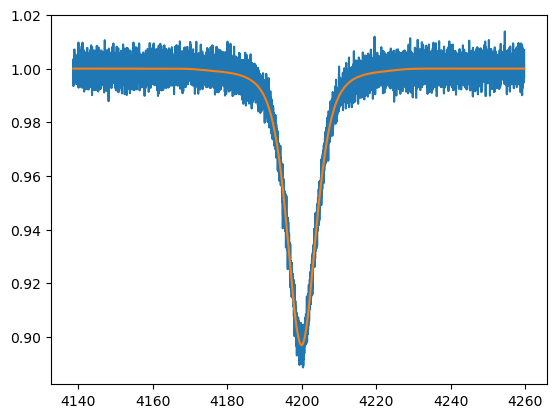

In [7]:
plt.plot(wave_obs, flux_noisy)
plt.plot(wave_obs, flux_true)

In [8]:
grid_dir = Path("/home/c4011027/PhD_stuff/SPAMMS/Outputs/results/zetaR_zetaT_inc_vcrit_grid")
line_name = "HEII4200"

# ------------------------------------------------------------
# 1. Build full model table from the whole grid
# ------------------------------------------------------------
def parse_model_info(model_info_path):
    params = {}

    with open(model_info_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        line = line.strip()
        if not line or line.startswith("#"):
            continue

        parts = re.split(r"\s*[:=]\s*|\s+", line)

        if len(parts) >= 2:
            key = parts[0].strip()
            val = parts[-1].strip()

            try:
                params[key] = float(val)
            except ValueError:
                params[key] = val

    return params


rows = []

for model_dir in sorted(grid_dir.glob("Model_*")):
    model_info = model_dir / "model_info.txt"

    if not model_info.exists():
        continue

    params = parse_model_info(model_info)

    profile_files = list(model_dir.glob(f"**/*{line_name}*.txt"))

    if len(profile_files) == 0:
        profile_file = None
    else:
        profile_file = profile_files[0]

    rows.append({
        "model_dir": str(model_dir),
        "model_name": model_dir.name,
        "inclination": params.get("inclination", np.nan),
        "v_crit_frac": params.get("v_crit_frac", np.nan),
        "sigma_R": params.get("sigma_R", np.nan),
        "sigma_T": params.get("sigma_T", np.nan),
        "profile_file": str(profile_file) if profile_file is not None else None,
    })

df_grid = pd.DataFrame(rows)
df_grid = df_grid.dropna(subset=["profile_file"]).reset_index(drop=True)

print(df_grid.head())
print(f"Found {len(df_grid)} usable model profiles in full grid.")

                                           model_dir  model_name  inclination  \
0  /home/c4011027/PhD_stuff/SPAMMS/Outputs/result...  Model_0000         10.0   
1  /home/c4011027/PhD_stuff/SPAMMS/Outputs/result...  Model_0001         30.0   
2  /home/c4011027/PhD_stuff/SPAMMS/Outputs/result...  Model_0002         50.0   
3  /home/c4011027/PhD_stuff/SPAMMS/Outputs/result...  Model_0003         70.0   
4  /home/c4011027/PhD_stuff/SPAMMS/Outputs/result...  Model_0004         90.0   

   v_crit_frac  sigma_R  sigma_T  \
0          0.1    100.0    100.0   
1          0.1    100.0    100.0   
2          0.1    100.0    100.0   
3          0.1    100.0    100.0   
4          0.1    100.0    100.0   

                                        profile_file  
0  /home/c4011027/PhD_stuff/SPAMMS/Outputs/result...  
1  /home/c4011027/PhD_stuff/SPAMMS/Outputs/result...  
2  /home/c4011027/PhD_stuff/SPAMMS/Outputs/result...  
3  /home/c4011027/PhD_stuff/SPAMMS/Outputs/result...  
4  /home/c4011027/PhD

In [9]:
chi_rows = []

for _, row in df_grid.iterrows():
    model_file = Path(row["profile_file"])

    model_data = np.loadtxt(model_file)
    wave_model = model_data[:, 0]
    flux_model = model_data[:, 1]

    if fit_window is not None:
        mask_model = (wave_model >= fit_window[0]) & (wave_model <= fit_window[1])
        wave_model = wave_model[mask_model]
        flux_model = flux_model[mask_model]

    flux_model_interp = np.interp(wave_obs, wave_model, flux_model)

    residual = flux_noisy - flux_model_interp

    chi2 = np.sum((residual / sigma_flux)**2)
    dof = len(wave_obs)
    red_chi2 = chi2 / dof

    chi_rows.append({
        "model_name": row["model_name"],
        "model_dir": row["model_dir"],
        "profile_file": row["profile_file"],
        "inclination": row["inclination"],
        "v_crit_frac": row["v_crit_frac"],
        "sigma_R": row["sigma_R"],
        "sigma_T": row["sigma_T"],
        "chi2": chi2,
        "red_chi2": red_chi2,
    })

df_chi = pd.DataFrame(chi_rows)
df_chi = df_chi.sort_values("chi2").reset_index(drop=True)

print("Best-fitting models from full grid:")
print(df_chi[[
    "model_name", "inclination", "v_crit_frac", "sigma_R", "sigma_T", "chi2", "red_chi2"
]].head(20))

Best-fitting models from full grid:
    model_name  inclination  v_crit_frac  sigma_R  sigma_T          chi2  \
0   Model_0400         10.0          0.1    200.0    300.0  12248.803895   
1   Model_0401         30.0          0.1    200.0    300.0  12253.605252   
2   Model_0477         50.0          0.1    250.0    150.0  12274.547721   
3   Model_0479         90.0          0.1    250.0    150.0  12309.443920   
4   Model_0403         70.0          0.1    200.0    300.0  12310.408336   
5   Model_0404         90.0          0.1    200.0    300.0  12316.739570   
6   Model_0382         50.0          0.3    200.0    250.0  12320.213712   
7   Model_0402         50.0          0.1    200.0    300.0  12336.624564   
8   Model_0505         10.0          0.3    250.0    200.0  12339.250783   
9   Model_0282         50.0          0.3    150.0    350.0  12352.439247   
10  Model_0501         30.0          0.1    250.0    200.0  12353.033188   
11  Model_0405         10.0          0.3    200.0   

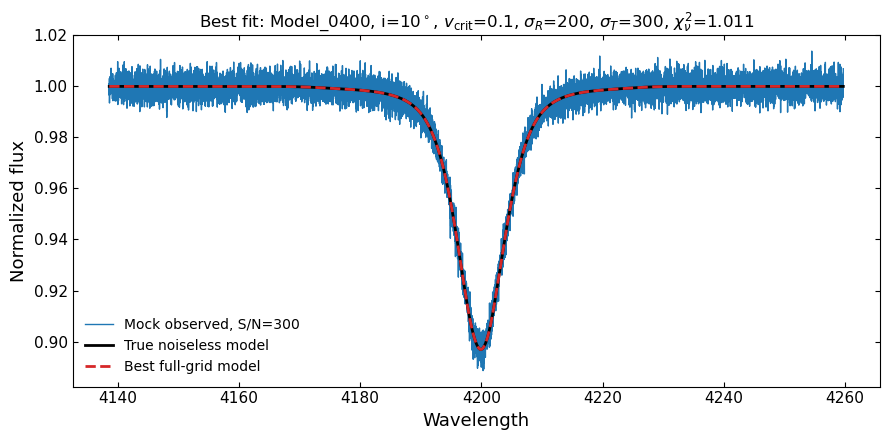

In [10]:
best_row = df_chi.iloc[0]
best_data = np.loadtxt(best_row["profile_file"])

wave_best = best_data[:, 0]
flux_best = best_data[:, 1]

if fit_window is not None:
    mask_best = (wave_best >= fit_window[0]) & (wave_best <= fit_window[1])
    wave_best = wave_best[mask_best]
    flux_best = flux_best[mask_best]

flux_best_interp = np.interp(wave_obs, wave_best, flux_best)

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(wave_obs, flux_noisy, lw=1.0, color="tab:blue", label=f"Mock observed, S/N={snr}")
ax.plot(wave_obs, flux_true, lw=2.0, color="black", label="True noiseless model")
ax.plot(wave_obs, flux_best_interp, lw=2.0, color="tab:red", ls="--", label="Best full-grid model")

ax.set_xlabel("Wavelength", fontsize=13)
ax.set_ylabel("Normalized flux", fontsize=13)

ax.set_title(
    rf"Best fit: {best_row['model_name']}, "
    rf"i={best_row['inclination']:.0f}$^\circ$, "
    rf"$v_\mathrm{{crit}}$={best_row['v_crit_frac']:.1f}, "
    rf"$\sigma_R$={best_row['sigma_R']:.0f}, "
    rf"$\sigma_T$={best_row['sigma_T']:.0f}, "
    rf"$\chi^2_\nu$={best_row['red_chi2']:.3f}",
    fontsize=12,
)

ax.tick_params(axis="both", labelsize=11, direction="in", top=True, right=True)
ax.legend(fontsize=10, frameon=False)

plt.tight_layout()
plt.show()

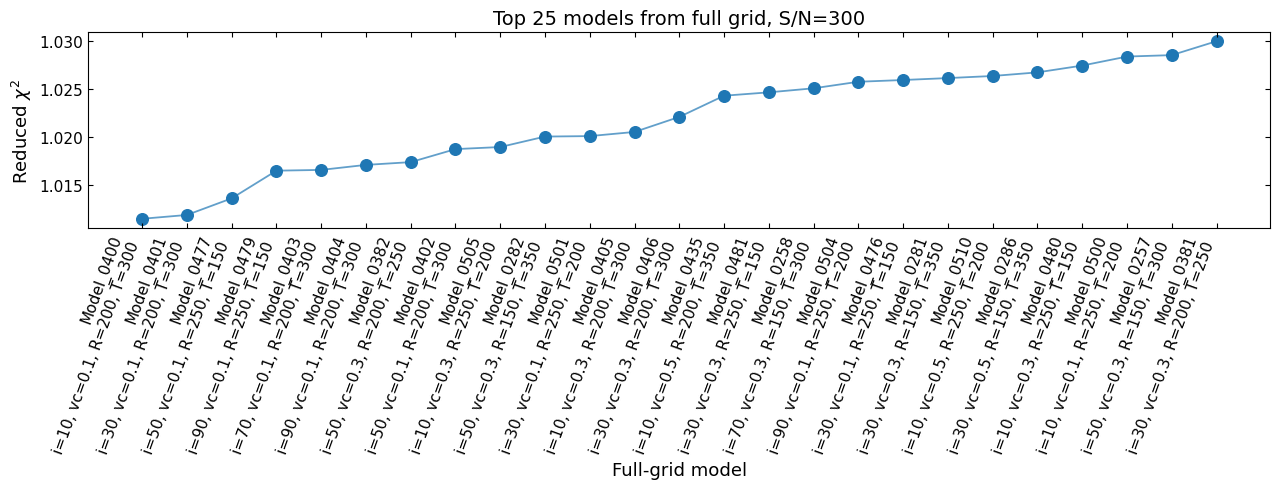

In [11]:
top_n = 25
dtop = df_chi.head(top_n).copy()

labels = [
    rf"{name}" + "\n" +
    rf"i={inc:.0f}, vc={vc:.1f}, R={sr:.0f}, T={st:.0f}"
    for name, inc, vc, sr, st in zip(
        dtop["model_name"],
        dtop["inclination"],
        dtop["v_crit_frac"],
        dtop["sigma_R"],
        dtop["sigma_T"],
    )
]

fig, ax = plt.subplots(figsize=(13, 5))

x = np.arange(len(dtop))

ax.scatter(x, dtop["red_chi2"], s=70, color="tab:blue")
ax.plot(x, dtop["red_chi2"], lw=1.3, color="tab:blue", alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=70, ha="right", fontsize=9)

ax.set_ylabel(r"Reduced $\chi^2$", fontsize=13)
ax.set_xlabel("Full-grid model", fontsize=13)
ax.set_title(rf"Top {top_n} models from full grid, S/N={snr}", fontsize=14)

ax.tick_params(axis="both", labelsize=11, direction="in", top=True, right=True)

plt.tight_layout()
plt.show()

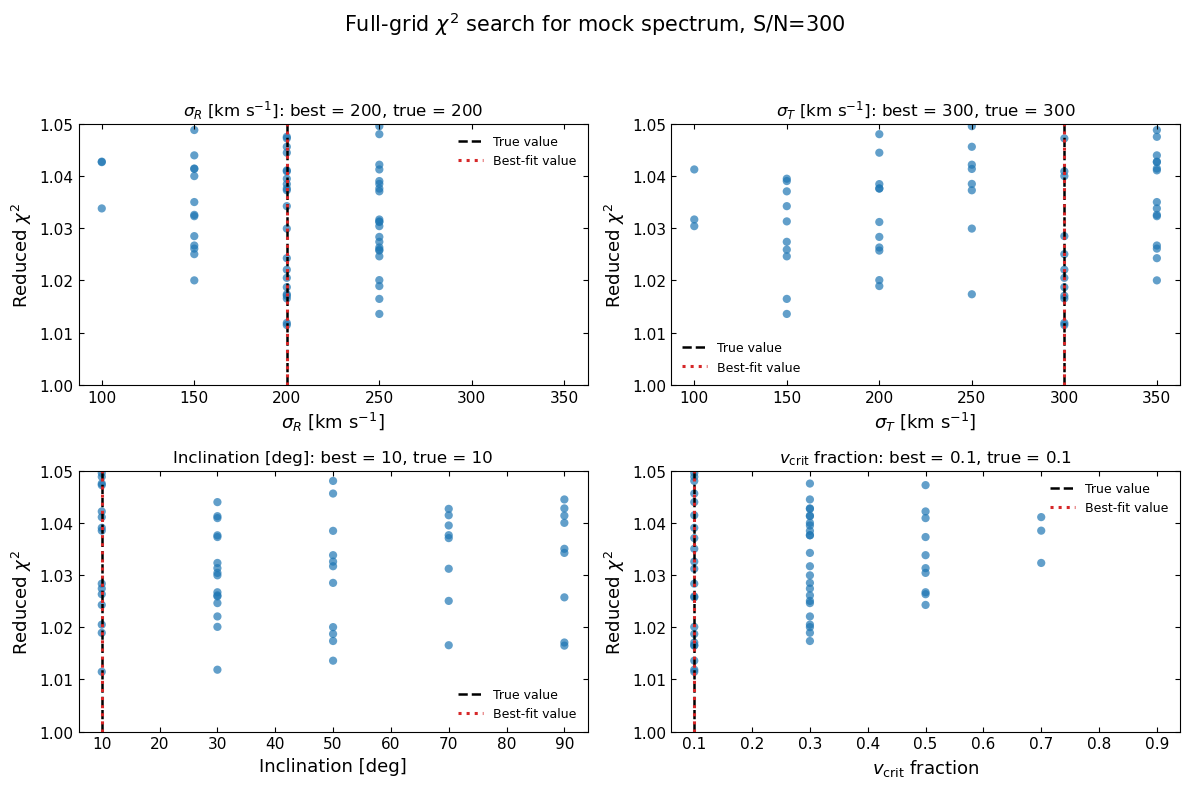

In [12]:
chi_col = "red_chi2"
#chi_col = "chi2"

params = [
    ("sigma_R", r"$\sigma_R$ [km s$^{-1}$]"),
    ("sigma_T", r"$\sigma_T$ [km s$^{-1}$]"),
    ("inclination", r"Inclination [deg]"),
    ("v_crit_frac", r"$v_\mathrm{crit}$ fraction"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, (param, xlabel) in zip(axes, params):
    ax.scatter(
        df_chi[param],
        df_chi[chi_col],
        s=35,
        alpha=0.7,
        color="tab:blue",
        edgecolor="none",
    )

    # Mark the true/mock value
    true_val = obs_row[param]
    ax.axvline(true_val, color="black", ls="--", lw=1.8, label="True value")

    # Mark the best-fit value
    best_val = df_chi.iloc[0][param]
    ax.axvline(best_val, color="tab:red", ls=":", lw=2.2, label="Best-fit value")

    ax.set_xlabel(xlabel, fontsize=13)
    ax.set_ylabel(r"Reduced $\chi^2$" if chi_col == "red_chi2" else r"$\chi^2$", fontsize=13)

    ax.tick_params(axis="both", labelsize=11, direction="in", top=True, right=True)

    ax.set_title(
        rf"{xlabel}: best = {best_val:g}, true = {true_val:g}",
        fontsize=12,
    )

    ax.legend(fontsize=9, frameon=False)
    ax.set_ylim(1, 1.05)

fig.suptitle(
    rf"Full-grid $\chi^2$ search for mock spectrum, S/N={snr}",
    fontsize=15,
)

fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

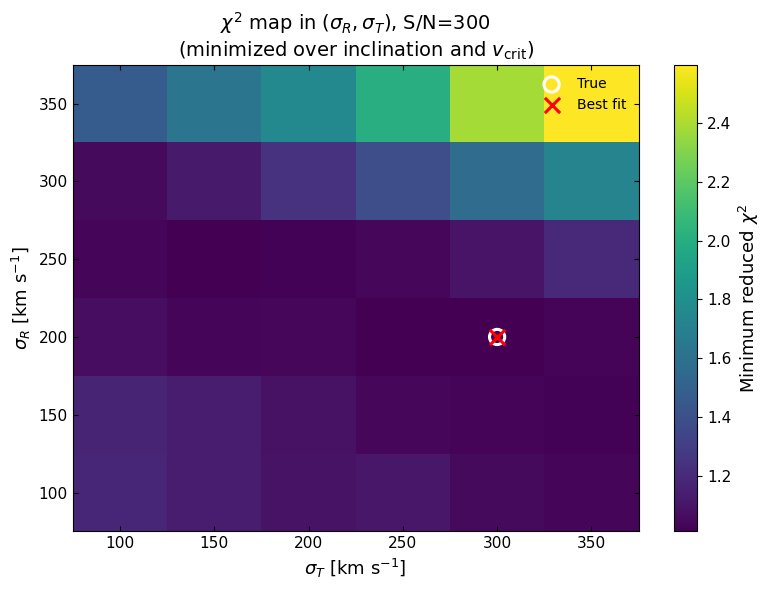

In [13]:
chi_col = "red_chi2"
# chi_col = "chi2"

# ------------------------------------------------------------
# For each (sigma_R, sigma_T), take the minimum chi-square
# over all inclination and v_crit_frac values
# ------------------------------------------------------------
d2 = (
    df_chi
    .groupby(["sigma_R", "sigma_T"], as_index=False)[chi_col]
    .min()
)

sigma_R_vals = np.sort(d2["sigma_R"].unique())
sigma_T_vals = np.sort(d2["sigma_T"].unique())

chi_map = np.full((len(sigma_R_vals), len(sigma_T_vals)), np.nan)

for i, sr in enumerate(sigma_R_vals):
    for j, st in enumerate(sigma_T_vals):
        m = d2[(d2["sigma_R"] == sr) & (d2["sigma_T"] == st)]
        if len(m) > 0:
            chi_map[i, j] = m[chi_col].values[0]

# ------------------------------------------------------------
# Helper: convert grid centers to edges for pcolormesh
# ------------------------------------------------------------
def centers_to_edges(x):
    x = np.asarray(x, dtype=float)
    if len(x) == 1:
        dx = 1.0
        return np.array([x[0] - dx/2, x[0] + dx/2])
    edges = np.empty(len(x) + 1)
    edges[1:-1] = 0.5 * (x[:-1] + x[1:])
    edges[0] = x[0] - 0.5 * (x[1] - x[0])
    edges[-1] = x[-1] + 0.5 * (x[-1] - x[-2])
    return edges

sigma_T_edges = centers_to_edges(sigma_T_vals)
sigma_R_edges = centers_to_edges(sigma_R_vals)

# ------------------------------------------------------------
# True and best-fit values
# ------------------------------------------------------------
true_sigma_R = obs_row["sigma_R"]
true_sigma_T = obs_row["sigma_T"]

best_row = df_chi.iloc[0]
best_sigma_R = best_row["sigma_R"]
best_sigma_T = best_row["sigma_T"]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

pcm = ax.pcolormesh(
    sigma_T_edges,
    sigma_R_edges,
    chi_map,
    shading="auto"
)

cbar = plt.colorbar(pcm, ax=ax)
cbar.set_label(r"Minimum reduced $\chi^2$" if chi_col == "red_chi2" else r"Minimum $\chi^2$", fontsize=13)
cbar.ax.tick_params(labelsize=11)

# Mark true value
ax.scatter(
    true_sigma_T, true_sigma_R,
    marker="o", s=120, facecolors="none", edgecolors="white", linewidths=2.2,
    label="True"
)

# Mark best-fit value
ax.scatter(
    best_sigma_T, best_sigma_R,
    marker="x", s=120, color="red", linewidths=2.2,
    label="Best fit"
)

ax.set_xlabel(r"$\sigma_T$ [km s$^{-1}$]", fontsize=13)
ax.set_ylabel(r"$\sigma_R$ [km s$^{-1}$]", fontsize=13)
ax.set_title(
    rf"$\chi^2$ map in $(\sigma_R,\sigma_T)$, S/N={snr}" "\n"
    rf"(minimized over inclination and $v_{{\rm crit}}$)",
    fontsize=14
)

ax.tick_params(axis="both", labelsize=11, direction="in", top=True, right=True)
ax.legend(fontsize=10, frameon=False)

plt.tight_layout()
plt.show()

In [30]:
df_profiles

,model_dir,model_name,inclination,v_crit_frac,sigma_R,sigma_T,profile_file
0,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...,Model_0400,10.0,0.1,200.0,300.0,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...
1,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...,Model_0410,10.0,0.5,200.0,300.0,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...
2,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...,Model_0420,10.0,0.9,200.0,300.0,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...
3,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...,Model_0401,30.0,0.1,200.0,300.0,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...
4,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...,Model_0411,30.0,0.5,200.0,300.0,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...
5,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...,Model_0421,30.0,0.9,200.0,300.0,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...
6,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...,Model_0404,90.0,0.1,200.0,300.0,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...
7,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...,Model_0414,90.0,0.5,200.0,300.0,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...
8,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...,Model_0424,90.0,0.9,200.0,300.0,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...


In [31]:
snr_values = [100, 300, 500]
rng = np.random.default_rng(42)

# Use first selected model as mock observed spectrum
obs_row = df_profiles.iloc[7]
obs_file = Path(obs_row["profile_file"])

# Optional fitting window
fit_window = None
# fit_window = (4185, 4215)

# Use chi2, not reduced chi2, for landscapes
chi_col = "chi2"

# ============================================================
# Read true/mock spectrum
# ============================================================
obs_data = np.loadtxt(obs_file)
wave_obs_full = obs_data[:, 0]
flux_true_full = obs_data[:, 1]

if fit_window is not None:
    mask_obs = (wave_obs_full >= fit_window[0]) & (wave_obs_full <= fit_window[1])
    wave_obs = wave_obs_full[mask_obs]
    flux_true = flux_true_full[mask_obs]
else:
    wave_obs = wave_obs_full.copy()
    flux_true = flux_true_full.copy()

print("Mock observed model:")
print(obs_row[["model_name", "inclination", "v_crit_frac", "sigma_R", "sigma_T"]])

# ============================================================
# Pre-load full grid model spectra onto observed wavelength grid
# This avoids reading/interpolating the same model repeatedly
# ============================================================
model_fluxes = []
model_rows = []

for _, row in df_grid.iterrows():
    model_file = Path(row["profile_file"])
    data = np.loadtxt(model_file)

    wave_model = data[:, 0]
    flux_model = data[:, 1]

    if fit_window is not None:
        mask_model = (wave_model >= fit_window[0]) & (wave_model <= fit_window[1])
        wave_model = wave_model[mask_model]
        flux_model = flux_model[mask_model]

    flux_model_interp = np.interp(wave_obs, wave_model, flux_model)

    model_fluxes.append(flux_model_interp)
    model_rows.append(row)

model_fluxes = np.asarray(model_fluxes)
df_model_rows = pd.DataFrame(model_rows).reset_index(drop=True)

print(f"Loaded {len(df_model_rows)} full-grid models.")

# ============================================================
# Compute chi-square tables for each S/N
# ============================================================
chi_tables = {}

for snr in snr_values:
    sigma_flux = 1.0 / snr

    flux_noisy = flux_true + rng.normal(0.0, sigma_flux, size=flux_true.size)

    residuals = flux_noisy[None, :] - model_fluxes
    chi2_values = np.sum((residuals / sigma_flux)**2, axis=1)
    red_chi2_values = chi2_values / len(wave_obs)

    df_chi_snr = df_model_rows.copy()
    df_chi_snr["chi2"] = chi2_values
    df_chi_snr["red_chi2"] = red_chi2_values
    df_chi_snr = df_chi_snr.sort_values("chi2").reset_index(drop=True)

    chi_tables[snr] = df_chi_snr

    print(f"\nS/N = {snr}")
    print("Best-fit model:")
    print(df_chi_snr[[
        "model_name", "inclination", "v_crit_frac",
        "sigma_R", "sigma_T", "chi2", "red_chi2"
    ]].head(5))

Mock observed model:
model_name     Model_0414
inclination          90.0
v_crit_frac           0.5
sigma_R             200.0
sigma_T             300.0
Name: 7, dtype: object
Loaded 900 full-grid models.

S/N = 100
Best-fit model:
   model_name  inclination  v_crit_frac  sigma_R  sigma_T          chi2  \
0  Model_0414         90.0          0.5    200.0    300.0  12967.903300   
1  Model_0417         50.0          0.7    200.0    300.0  12971.486272   
2  Model_0489         90.0          0.5    250.0    150.0  12975.711476   
3  Model_0538         70.0          0.5    250.0    250.0  12976.288113   
4  Model_0439         90.0          0.5    200.0    350.0  12979.319711   

   red_chi2  
0  1.006747  
1  1.007025  
2  1.007353  
3  1.007398  
4  1.007633  

S/N = 300
Best-fit model:
   model_name  inclination  v_crit_frac  sigma_R  sigma_T          chi2  \
0  Model_0414         90.0          0.5    200.0    300.0  12888.436224   
1  Model_0417         50.0          0.7    200.0    300.0 

In [32]:
df_chi_snr

,model_dir,model_name,inclination,v_crit_frac,sigma_R,sigma_T,profile_file,chi2,red_chi2
0,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...,Model_0414,90.0,0.5,200.0,300.0,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...,13175.292291,1.022847
1,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...,Model_0417,50.0,0.7,200.0,300.0,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...,13298.568643,1.032417
2,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...,Model_0489,90.0,0.5,250.0,150.0,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...,13364.300426,1.037520
3,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...,Model_0571,30.0,0.9,250.0,300.0,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...,13416.924710,1.041606
4,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...,Model_0538,70.0,0.5,250.0,250.0,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...,13456.342561,1.044666
...,...,...,...,...,...,...,...,...,...
895,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...,Model_0040,10.0,0.7,100.0,150.0,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...,342268.190263,26.571554
896,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...,Model_0045,10.0,0.9,100.0,150.0,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...,355519.794685,27.600326
897,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...,Model_0010,10.0,0.5,100.0,100.0,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...,359520.632326,27.910926
898,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...,Model_0015,10.0,0.7,100.0,100.0,/home/c4011027/PhD_stuff/SPAMMS/Outputs/result...,387898.432359,30.114000


In [33]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Add projected rotation fraction to all chi-square tables
# ============================================================

for snr in snr_values:
    chi_tables[snr]["vcrit_sini"] = (
        chi_tables[snr]["v_crit_frac"]
        * np.sin(np.deg2rad(chi_tables[snr]["inclination"]))
    )

# True/mock projected rotation fraction
true_vcrit_sini = (
    obs_row["v_crit_frac"]
    * np.sin(np.deg2rad(obs_row["inclination"]))
)

print(f"True vcrit_frac * sin(i) = {true_vcrit_sini:.4f}")

True vcrit_frac * sin(i) = 0.5000


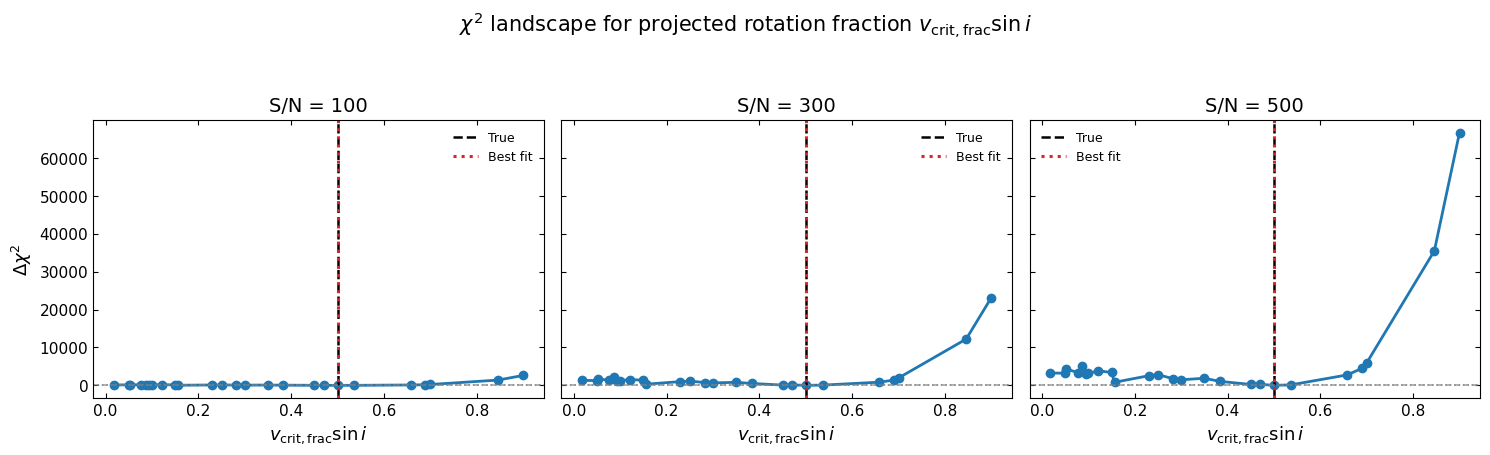

In [34]:
# ============================================================
# Plot chi-square landscape for vcrit_frac * sin(i)
# For each vcrit_sini, minimize chi2 over sigma_R, sigma_T,
# inclination, and v_crit_frac combinations that share that value
# ============================================================

chi_col = "chi2"

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)

for ax, snr in zip(axes, snr_values):
    df_chi_snr = chi_tables[snr].copy()

    # Round because multiple inc/vcrit combinations may give very close values
    df_chi_snr["vcrit_sini_round"] = df_chi_snr["vcrit_sini"].round(4)

    dland = (
        df_chi_snr
        .groupby("vcrit_sini_round", as_index=False)[chi_col]
        .min()
        .sort_values("vcrit_sini_round")
    )

    dland["delta_chi2"] = dland[chi_col] - dland[chi_col].min()

    best_vcrit_sini = df_chi_snr.iloc[0]["vcrit_sini"]

    ax.plot(
        dland["vcrit_sini_round"],
        dland["delta_chi2"],
        marker="o",
        lw=2.0,
        color="tab:blue"
    )

    ax.axvline(
        true_vcrit_sini,
        color="black",
        ls="--",
        lw=1.8,
        label="True"
    )

    ax.axvline(
        best_vcrit_sini,
        color="tab:red",
        ls=":",
        lw=2.2,
        label="Best fit"
    )

    ax.axhline(1.0, color="gray", ls="--", lw=1.2, alpha=0.7)
    ax.axhline(9.0, color="gray", ls=":", lw=1.2, alpha=0.7)

    ax.set_xlabel(r"$v_\mathrm{crit,frac}\sin i$", fontsize=13)
    ax.set_title(rf"S/N = {snr}", fontsize=14)

    ax.tick_params(axis="both", labelsize=11, direction="in", top=True, right=True)
    ax.legend(fontsize=9, frameon=False)

axes[0].set_ylabel(r"$\Delta \chi^2$", fontsize=13)

fig.suptitle(
    rf"$\chi^2$ landscape for projected rotation fraction "
    rf"$v_\mathrm{{crit,frac}}\sin i$",
    fontsize=15
)

fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

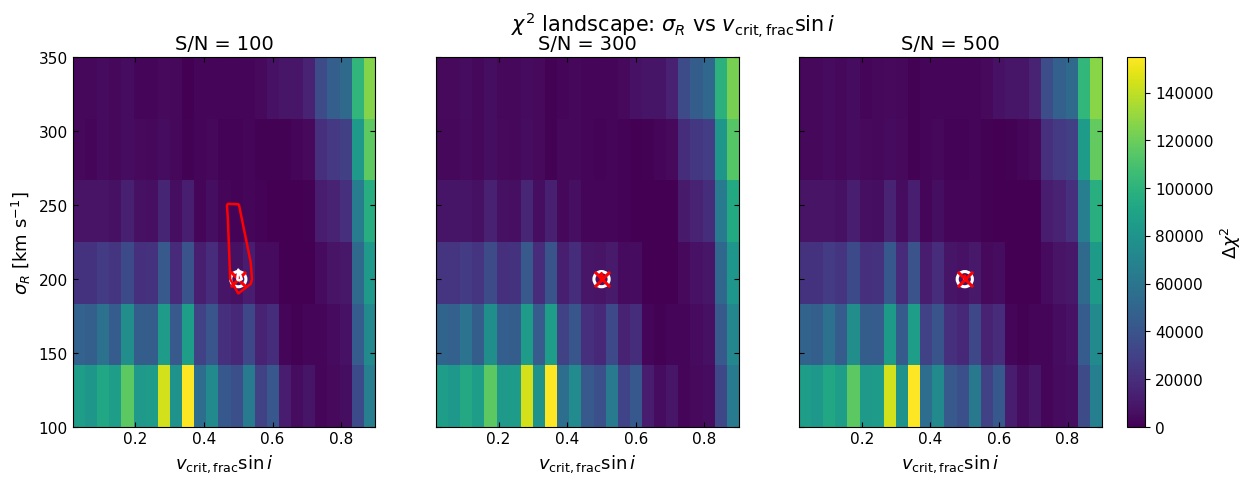

In [35]:
# ============================================================
# 2D chi-square landscape: sigma_R vs vcrit_frac * sin(i)
# Minimized over sigma_T and over all geometry combinations
# ============================================================

chi_col = "chi2"

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True, sharey=True)

for ax, snr in zip(axes, snr_values):
    df_chi_snr = chi_tables[snr].copy()
    df_chi_snr["vcrit_sini_round"] = df_chi_snr["vcrit_sini"].round(4)

    d2 = (
        df_chi_snr
        .groupby(["vcrit_sini_round", "sigma_R"], as_index=False)[chi_col]
        .min()
    )

    d2["delta_chi2"] = d2[chi_col] - d2[chi_col].min()

    xvals = np.sort(d2["vcrit_sini_round"].unique())
    yvals = np.sort(d2["sigma_R"].unique())

    zmap = np.full((len(yvals), len(xvals)), np.nan)

    for i, sr in enumerate(yvals):
        for j, vsini_frac in enumerate(xvals):
            m = d2[
                (d2["sigma_R"] == sr)
                & (d2["vcrit_sini_round"] == vsini_frac)
            ]
            if len(m) > 0:
                zmap[i, j] = m["delta_chi2"].values[0]

    im = ax.imshow(
        zmap,
        origin="lower",
        aspect="auto",
        extent=[xvals.min(), xvals.max(), yvals.min(), yvals.max()],
        interpolation="nearest"
    )

    ax.contour(
        xvals,
        yvals,
        zmap,
        levels=[1.0, 9.0],
        colors=["white", "red"],
        linewidths=[1.8, 1.8]
    )

    best_row = df_chi_snr.iloc[0]

    ax.scatter(
        true_vcrit_sini,
        obs_row["sigma_R"],
        marker="o",
        s=120,
        facecolors="none",
        edgecolors="white",
        linewidths=2.2,
        label="True"
    )

    ax.scatter(
        best_row["vcrit_sini"],
        best_row["sigma_R"],
        marker="x",
        s=120,
        color="red",
        linewidths=2.2,
        label="Best fit"
    )

    ax.set_title(rf"S/N = {snr}", fontsize=14)
    ax.set_xlabel(r"$v_\mathrm{crit,frac}\sin i$", fontsize=13)

    ax.tick_params(axis="both", labelsize=11, direction="in", top=True, right=True)

axes[0].set_ylabel(r"$\sigma_R$ [km s$^{-1}$]", fontsize=13)

cbar = fig.colorbar(im, ax=axes, pad=0.02)
cbar.set_label(r"$\Delta \chi^2$", fontsize=13)
cbar.ax.tick_params(labelsize=11)

fig.suptitle(
    rf"$\chi^2$ landscape: $\sigma_R$ vs $v_\mathrm{{crit,frac}}\sin i$",
    fontsize=15
)

#fig.tight_layout(rect=[0, 0, 0.92, 0.92])
plt.show()

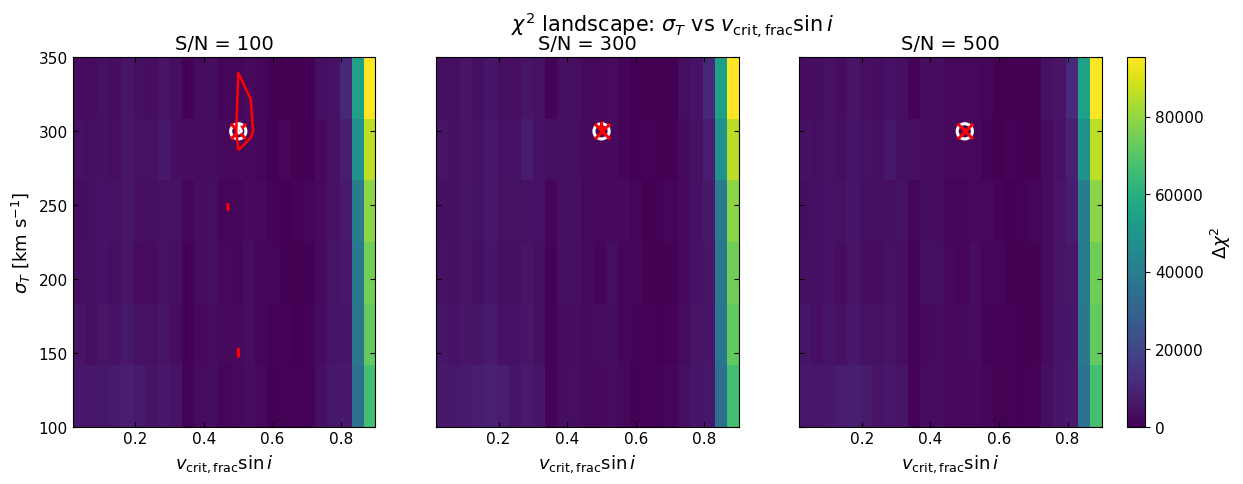

In [36]:
# ============================================================
# 2D chi-square landscape: sigma_T vs vcrit_frac * sin(i)
# Minimized over sigma_R and over all geometry combinations
# ============================================================

chi_col = "chi2"

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True, sharey=True)

for ax, snr in zip(axes, snr_values):
    df_chi_snr = chi_tables[snr].copy()
    df_chi_snr["vcrit_sini_round"] = df_chi_snr["vcrit_sini"].round(4)

    d2 = (
        df_chi_snr
        .groupby(["vcrit_sini_round", "sigma_T"], as_index=False)[chi_col]
        .min()
    )

    d2["delta_chi2"] = d2[chi_col] - d2[chi_col].min()

    xvals = np.sort(d2["vcrit_sini_round"].unique())
    yvals = np.sort(d2["sigma_T"].unique())

    zmap = np.full((len(yvals), len(xvals)), np.nan)

    for i, st in enumerate(yvals):
        for j, vsini_frac in enumerate(xvals):
            m = d2[
                (d2["sigma_T"] == st)
                & (d2["vcrit_sini_round"] == vsini_frac)
            ]
            if len(m) > 0:
                zmap[i, j] = m["delta_chi2"].values[0]

    im = ax.imshow(
        zmap,
        origin="lower",
        aspect="auto",
        extent=[xvals.min(), xvals.max(), yvals.min(), yvals.max()],
        interpolation="nearest"
    )

    ax.contour(
        xvals,
        yvals,
        zmap,
        levels=[1.0, 9.0],
        colors=["white", "red"],
        linewidths=[1.8, 1.8]
    )

    best_row = df_chi_snr.iloc[0]

    ax.scatter(
        true_vcrit_sini,
        obs_row["sigma_T"],
        marker="o",
        s=120,
        facecolors="none",
        edgecolors="white",
        linewidths=2.2,
        label="True"
    )

    ax.scatter(
        best_row["vcrit_sini"],
        best_row["sigma_T"],
        marker="x",
        s=120,
        color="red",
        linewidths=2.2,
        label="Best fit"
    )

    ax.set_title(rf"S/N = {snr}", fontsize=14)
    ax.set_xlabel(r"$v_\mathrm{crit,frac}\sin i$", fontsize=13)

    ax.tick_params(axis="both", labelsize=11, direction="in", top=True, right=True)

axes[0].set_ylabel(r"$\sigma_T$ [km s$^{-1}$]", fontsize=13)

cbar = fig.colorbar(im, ax=axes, pad=0.02)
cbar.set_label(r"$\Delta \chi^2$", fontsize=13)
cbar.ax.tick_params(labelsize=11)

fig.suptitle(
    rf"$\chi^2$ landscape: $\sigma_T$ vs $v_\mathrm{{crit,frac}}\sin i$",
    fontsize=15
)

#fig.tight_layout(rect=[0, 0, 0.92, 0.92])
plt.show()

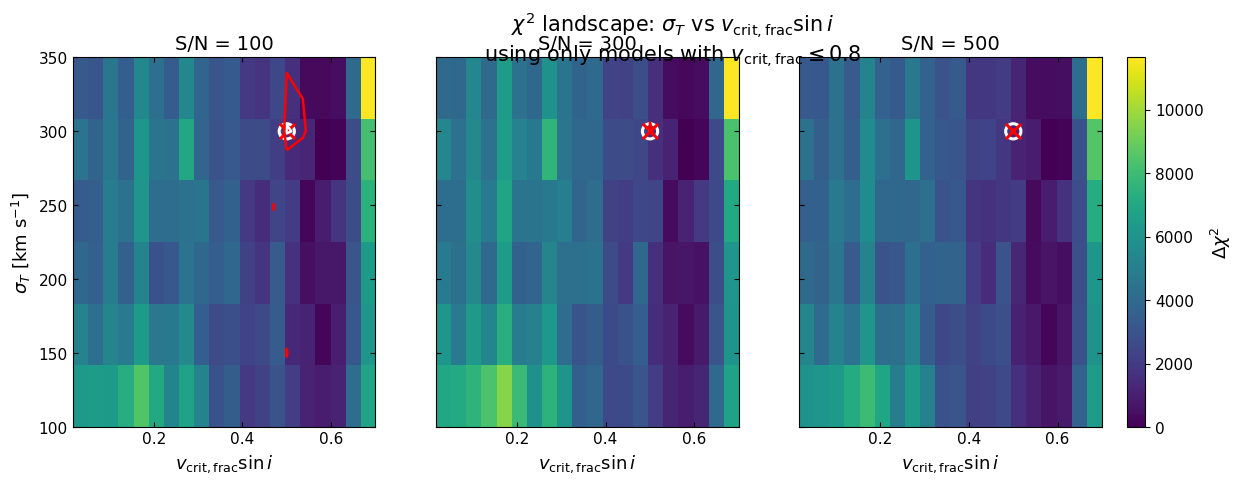

In [45]:
chi_col = "chi2"
vcrit_max = 0.8

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True, sharey=True)

ims = []

for ax, snr in zip(axes, snr_values):
    df_chi_snr = chi_tables[snr].copy()

    # --------------------------------------------------------
    # Filter before any grouping or delta-chi2 calculation
    # --------------------------------------------------------
    df_chi_snr = df_chi_snr[df_chi_snr["v_crit_frac"] <= vcrit_max].copy()

    df_chi_snr["vcrit_sini_round"] = df_chi_snr["vcrit_sini"].round(4)

    d2 = (
        df_chi_snr
        .groupby(["vcrit_sini_round", "sigma_T"], as_index=False)[chi_col]
        .min()
    )

    d2["delta_chi2"] = d2[chi_col] - d2[chi_col].min()

    xvals = np.sort(d2["vcrit_sini_round"].unique())
    yvals = np.sort(d2["sigma_T"].unique())

    zmap = np.full((len(yvals), len(xvals)), np.nan)

    for i, st in enumerate(yvals):
        for j, vsini_frac in enumerate(xvals):
            m = d2[
                (d2["sigma_T"] == st)
                & (d2["vcrit_sini_round"] == vsini_frac)
            ]
            if len(m) > 0:
                zmap[i, j] = m["delta_chi2"].values[0]

    im = ax.imshow(
        zmap,
        origin="lower",
        aspect="auto",
        extent=[xvals.min(), xvals.max(), yvals.min(), yvals.max()],
        interpolation="nearest"
    )

    ims.append(im)

    # Draw contours only if the requested levels exist in the filtered map
    finite_z = zmap[np.isfinite(zmap)]
    if finite_z.size > 0:
        contour_levels = [lev for lev in [1.0, 9.0] if finite_z.min() <= lev <= finite_z.max()]

        if len(contour_levels) > 0:
            ax.contour(
                xvals,
                yvals,
                zmap,
                levels=contour_levels,
                colors=["white" if lev == 1.0 else "red" for lev in contour_levels],
                linewidths=[1.8 for _ in contour_levels]
            )

    best_row = df_chi_snr.iloc[0]

    ax.scatter(
        true_vcrit_sini,
        obs_row["sigma_T"],
        marker="o",
        s=120,
        facecolors="none",
        edgecolors="white",
        linewidths=2.2,
        label="True"
    )

    ax.scatter(
        best_row["vcrit_sini"],
        best_row["sigma_T"],
        marker="x",
        s=120,
        color="red",
        linewidths=2.2,
        label="Best fit"
    )

    ax.set_title(rf"S/N = {snr}", fontsize=14)
    ax.set_xlabel(r"$v_\mathrm{crit,frac}\sin i$", fontsize=13)

    ax.tick_params(axis="both", labelsize=11, direction="in", top=True, right=True)

axes[0].set_ylabel(r"$\sigma_T$ [km s$^{-1}$]", fontsize=13)

cbar = fig.colorbar(ims[-1], ax=axes, pad=0.02)
cbar.set_label(r"$\Delta \chi^2$", fontsize=13)
cbar.ax.tick_params(labelsize=11)

fig.suptitle(
    rf"$\chi^2$ landscape: $\sigma_T$ vs $v_\mathrm{{crit,frac}}\sin i$"
    "\n"
    rf"using only models with $v_\mathrm{{crit,frac}} \leq {vcrit_max}$",
    fontsize=15
)

plt.show()

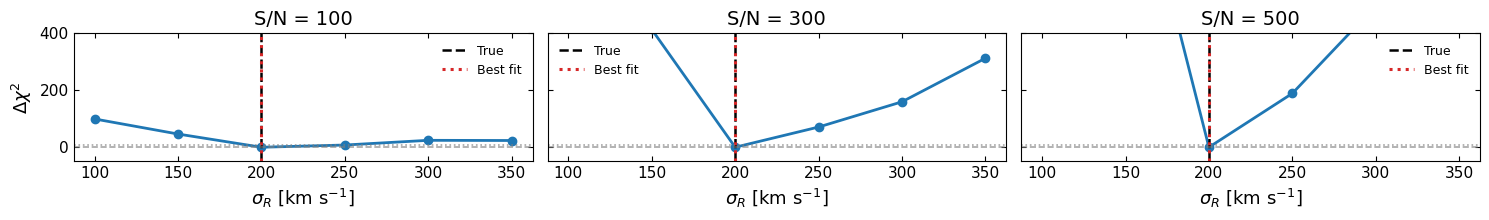

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(15, 2.5), sharey=True)

true_sigma_R = obs_row["sigma_R"]

for ax, snr in zip(axes, snr_values):
    df_chi_snr = chi_tables[snr]

    dland = (
        df_chi_snr
        .groupby("sigma_R", as_index=False)[chi_col]
        .min()
        .sort_values("sigma_R")
    )

    # Use delta chi2 so all panels are directly comparable around the minimum
    dland["delta_chi2"] = dland[chi_col] - dland[chi_col].min()

    best_sigma_R = df_chi_snr.iloc[0]["sigma_R"]

    ax.plot(
        dland["sigma_R"],
        dland["delta_chi2"],
        marker="o",
        lw=2.0,
        color="tab:blue"
    )

    ax.axvline(
        true_sigma_R,
        color="black",
        ls="--",
        lw=1.8,
        label="True"
    )

    ax.axvline(
        best_sigma_R,
        color="tab:red",
        ls=":",
        lw=2.2,
        label="Best fit"
    )

    ax.axhline(1.0, color="gray", ls="--", lw=1.2, alpha=0.7)
    ax.axhline(9.0, color="gray", ls=":", lw=1.2, alpha=0.7)

    ax.set_xlabel(r"$\sigma_R$ [km s$^{-1}$]", fontsize=13)
    ax.set_title(rf"S/N = {snr}", fontsize=14)

    ax.tick_params(axis="both", labelsize=11, direction="in", top=True, right=True)
    ax.legend(fontsize=9, frameon=False)
    ax.set_ylim(-50, 400)
axes[0].set_ylabel(r"$\Delta \chi^2$", fontsize=13)


fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

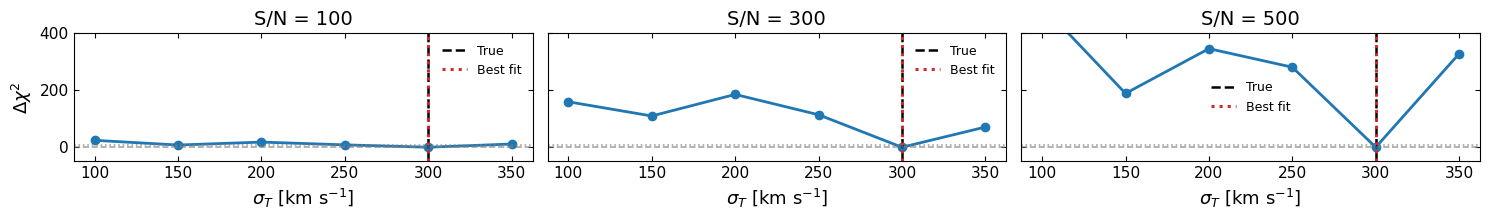

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 2.5), sharey=True)

true_sigma_T = obs_row["sigma_T"]

for ax, snr in zip(axes, snr_values):
    df_chi_snr = chi_tables[snr]

    dland = (
        df_chi_snr
        .groupby("sigma_T", as_index=False)[chi_col]
        .min()
        .sort_values("sigma_T")
    )

    # Use delta chi2 so all panels are directly comparable around the minimum
    dland["delta_chi2"] = dland[chi_col] - dland[chi_col].min()

    best_sigma_T = df_chi_snr.iloc[0]["sigma_T"]

    ax.plot(
        dland["sigma_T"],
        dland["delta_chi2"],
        marker="o",
        lw=2.0,
        color="tab:blue"
    )

    ax.axvline(
        true_sigma_T,
        color="black",
        ls="--",
        lw=1.8,
        label="True"
    )

    ax.axvline(
        best_sigma_T,
        color="tab:red",
        ls=":",
        lw=2.2,
        label="Best fit"
    )

    ax.axhline(1.0, color="gray", ls="--", lw=1.2, alpha=0.7)
    ax.axhline(9.0, color="gray", ls=":", lw=1.2, alpha=0.7)
    #ax.set_xlim(205, 385)
    ax.set_xlabel(r"$\sigma_T$ [km s$^{-1}$]", fontsize=13)
    ax.set_title(rf"S/N = {snr}", fontsize=14)

    ax.tick_params(axis="both", labelsize=11, direction="in", top=True, right=True)
    ax.legend(fontsize=9, frameon=False)
    ax.set_ylim(-50, 400)
axes[0].set_ylabel(r"$\Delta \chi^2$", fontsize=13)


fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

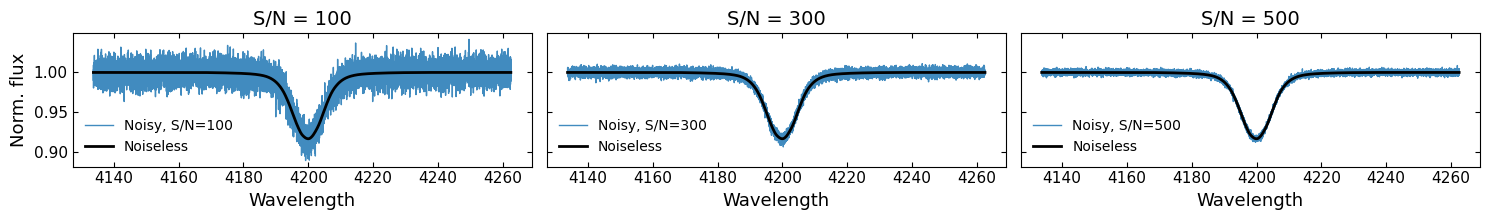

In [39]:
snr_values = [100, 300, 500]

# Use a fixed seed so this plot uses reproducible noise
rng = np.random.default_rng(42)

fig, axes = plt.subplots(1, 3, figsize=(15, 2.5), sharex=True, sharey=True)

for ax, snr in zip(axes, snr_values):
    sigma_flux = 1.0 / snr
    flux_noisy = flux_true + rng.normal(0.0, sigma_flux, size=flux_true.size)

    ax.plot(
        wave_obs,
        flux_noisy,
        lw=1.0,
        color="tab:blue",
        alpha=0.85,
        label=rf"Noisy, S/N={snr}"
    )

    ax.plot(
        wave_obs,
        flux_true,
        lw=2.0,
        color="black",
        label="Noiseless"
    )

    ax.set_title(rf"S/N = {snr}", fontsize=14)
    ax.set_xlabel("Wavelength", fontsize=13)

    ax.tick_params(axis="both", labelsize=11, direction="in", top=True, right=True)
    ax.legend(fontsize=10, frameon=False)

axes[0].set_ylabel("Norm. flux", fontsize=13)

fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()